In [1]:
print("Welcome to FarmSense AI 🌱")

Welcome to FarmSense AI 🌱


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Scikit-learn:", sklearn.__version__)

NumPy: 2.4.6
Pandas: 3.0.5
Scikit-learn: 1.9.0


In [1]:
import sys

print(sys.executable)
print(sys.version)


/Users/saiganeshnallani/Documents/FarmSense-AI/.venv/bin/python
3.11.16 (main, Aug 12 2026, 23:03:19) [Clang 21.0.0 (clang-2100.1.1.101)]


In [2]:
import pandas as pd
import xlrd

print("Pandas:", pd.__version__)
print("xlrd:", xlrd.__version__)
print("FarmSense environment is ready! 🌱")


Pandas: 3.0.5
xlrd: 2.0.2
FarmSense environment is ready! 🌱


In [5]:
import pandas as pd

data_path = "../data/raw/Crop_recommendation.xls"

df = pd.read_csv(data_path)

print("✅ Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])


✅ Dataset loaded successfully!
Rows: 2200
Columns: 8


In [6]:
df.head()


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [7]:
print(df.shape)


(2200, 8)


In [8]:
print(df.columns.tolist())

['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']


In [9]:
df.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [10]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [11]:
df["label"].value_counts()


label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

In [12]:
print("Number of different crops:", df["label"].nunique())

Number of different crops: 22


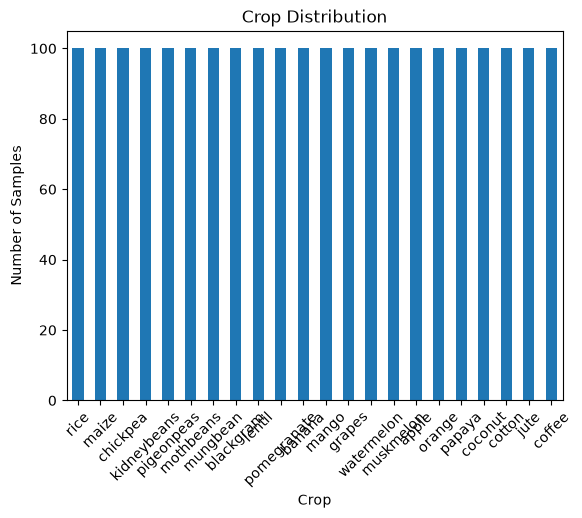

In [14]:
df["label"].value_counts()

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

In [15]:
print("Number of different crops:", df["label"].nunique())


Number of different crops: 22


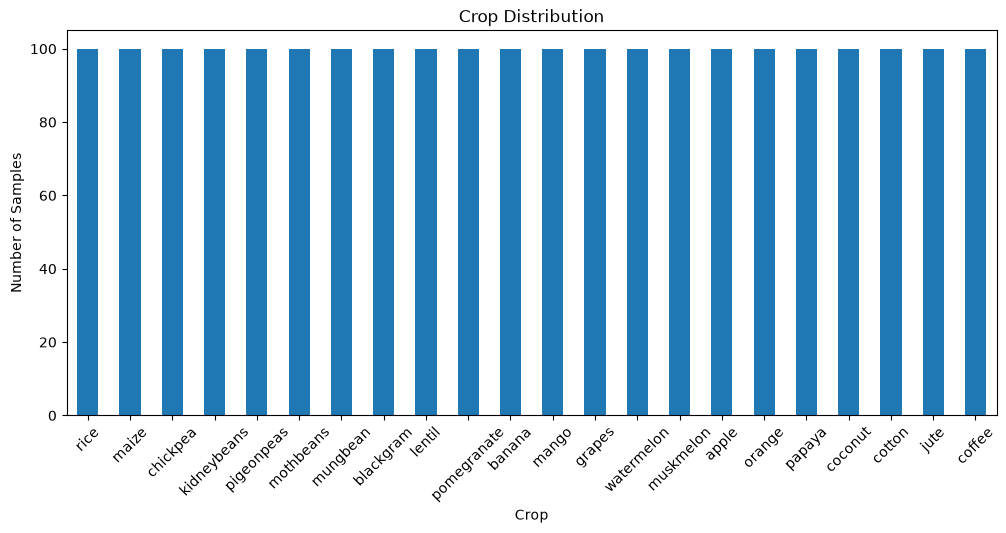

In [16]:
import matplotlib.pyplot as plt

df["label"].value_counts().plot(kind="bar", figsize=(12, 5))

plt.title("Crop Distribution")
plt.xlabel("Crop")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.show()


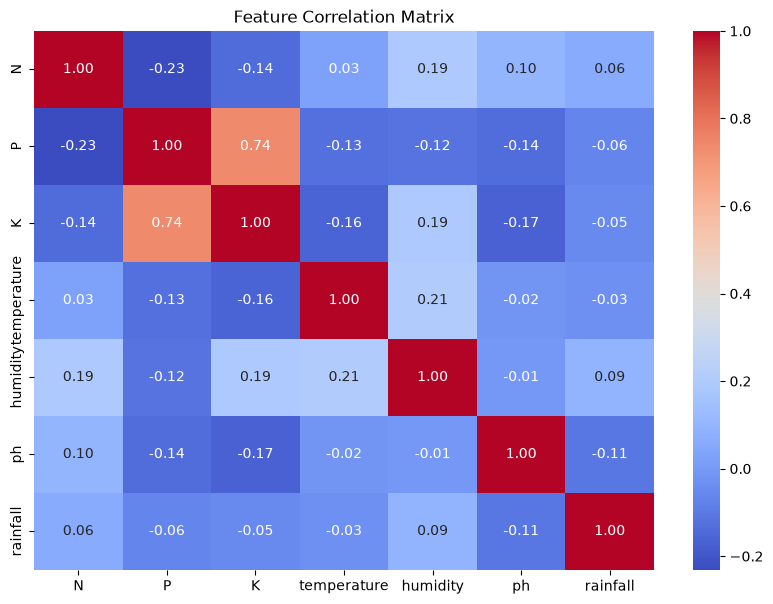

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

features = [
    "N",
    "P",
    "K",
    "temperature",
    "humidity",
    "ph",
    "rainfall"
]

correlation = df[features].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Matrix")
plt.show()

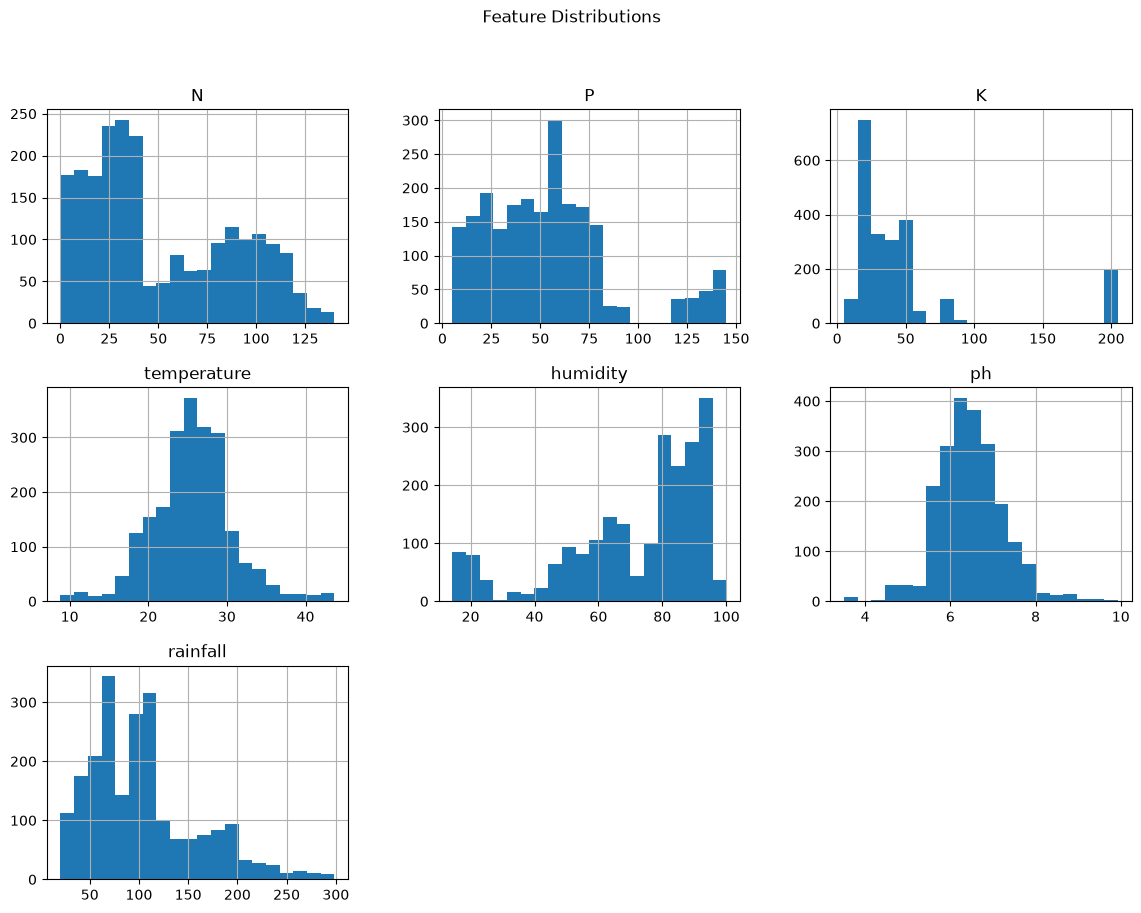

In [18]:
df[features].hist(
    figsize=(14, 10),
    bins=20
)

plt.suptitle("Feature Distributions")
plt.show()


In [19]:
X = df.drop("label", axis=1)
y = df["label"]

print("Input features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Input features:
['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

Target:
label

X shape: (2200, 7)
y shape: (2200,)


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 1760
Testing samples: 440


In [21]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

print("✅ Model trained successfully!")

✅ Model trained successfully!


In [22]:
y_pred = model.predict(X_test)

print("First 10 predictions:")
print(y_pred[:10])

print("\nActual values:")
print(y_test.iloc[:10].values)

First 10 predictions:
['orange' 'banana' 'cotton' 'maize' 'orange' 'chickpea' 'rice' 'blackgram'
 'banana' 'orange']

Actual values:
<StringArray>
[   'orange',    'banana',    'cotton',     'maize',    'orange',  'chickpea',
      'rice', 'blackgram',    'banana',    'orange']
Length: 10, dtype: str


In [23]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 0.9955
Accuracy: 99.55%


In [24]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        20
      papaya       1.00    

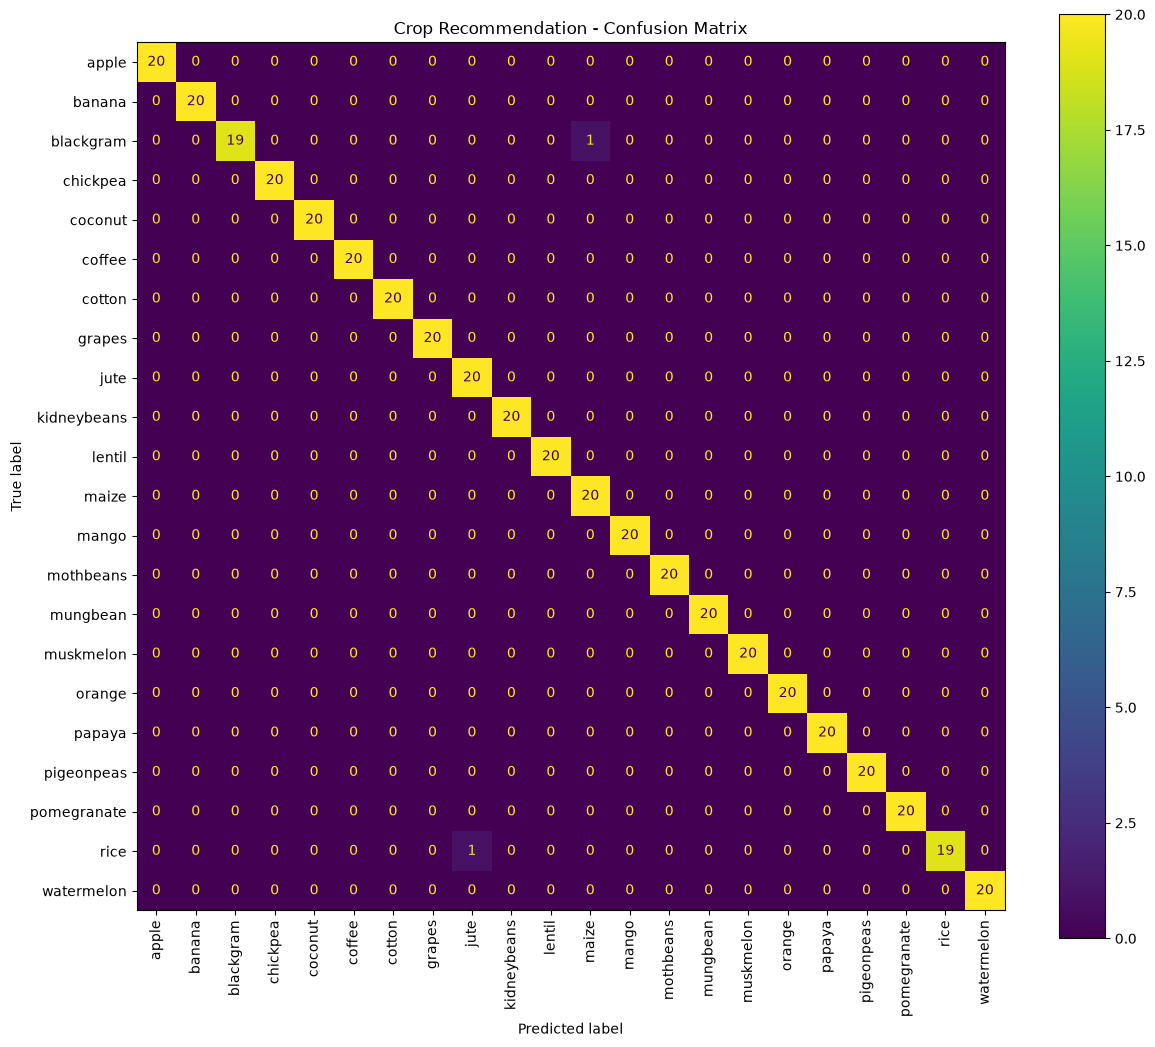

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

plt.figure(figsize=(14, 12))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot(
    xticks_rotation=90,
    ax=plt.gca()
)

plt.title("Crop Recommendation - Confusion Matrix")
plt.show()

In [26]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance)

rainfall       0.219641
humidity       0.217058
K              0.180813
P              0.151342
N              0.103356
temperature    0.075485
ph             0.052305
dtype: float64


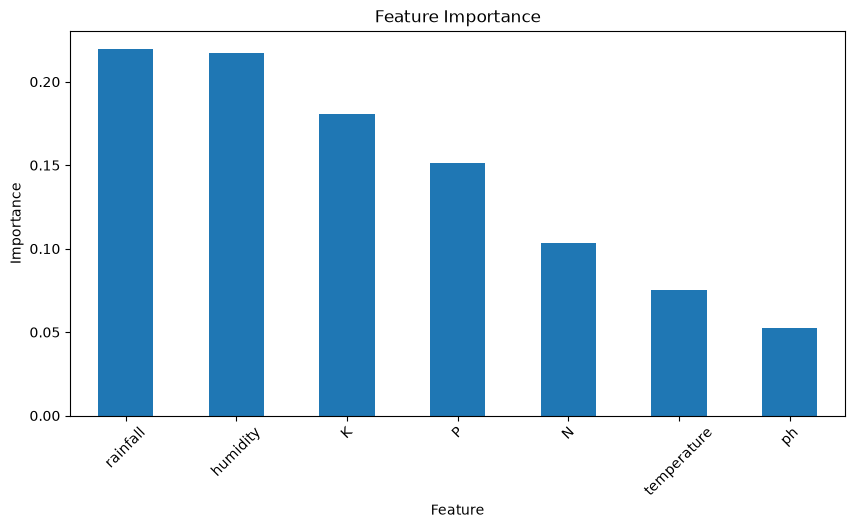

In [27]:
importance.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

results = {}

for name, clf in models.items():
    clf.fit(X_train, y_train)
    
    predictions = clf.predict(X_test)
    
    accuracy = accuracy_score(y_test, predictions)
    
    results[name] = accuracy
    
    print(f"{name}: {accuracy * 100:.2f}%")

/Users/saiganeshnallani/Documents/FarmSense-AI/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression: 97.95%
Decision Tree: 97.95%
Random Forest: 99.55%
Gradient Boosting: 98.86%


In [29]:
results_df = pd.DataFrame(
    list(results.items()),
    columns=["Model", "Accuracy"]
)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df

,Model,Accuracy
2,Random Forest,0.995455
3,Gradient Boosting,0.988636
0,Logistic Regression,0.979545
1,Decision Tree,0.979545


In [30]:
import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.51.0


In [31]:
import shap

# Create SHAP explainer for our Random Forest
explainer = shap.TreeExplainer(model)

# Calculate SHAP values for the test data
shap_values = explainer.shap_values(X_test)

print("✅ SHAP values calculated!")
print("Number of features:", X_test.shape[1])

✅ SHAP values calculated!
Number of features: 7


In [33]:
import numpy as np
import pandas as pd

# Convert SHAP output to NumPy array
shap_array = np.asarray(shap_values)

print("SHAP array shape:", shap_array.shape)
print("X_test shape:", X_test.shape)

SHAP array shape: (440, 7, 22)
X_test shape: (440, 7)


In [34]:
# Calculate average absolute SHAP importance
if shap_array.ndim == 3:
    # Expected format: samples × features × classes
    mean_importance = np.abs(shap_array).mean(axis=(0, 2))

elif shap_array.ndim == 2:
    # Binary/single-output format
    mean_importance = np.abs(shap_array).mean(axis=0)

else:
    raise ValueError(f"Unexpected SHAP shape: {shap_array.shape}")

shap_importance = pd.Series(
    mean_importance,
    index=X_test.columns
).sort_values(ascending=False)

print("Feature importance according to SHAP:")
print(shap_importance)

Feature importance according to SHAP:
humidity       0.032210
K              0.027700
rainfall       0.025954
N              0.025890
P              0.024153
temperature    0.010500
ph             0.004885
dtype: float64


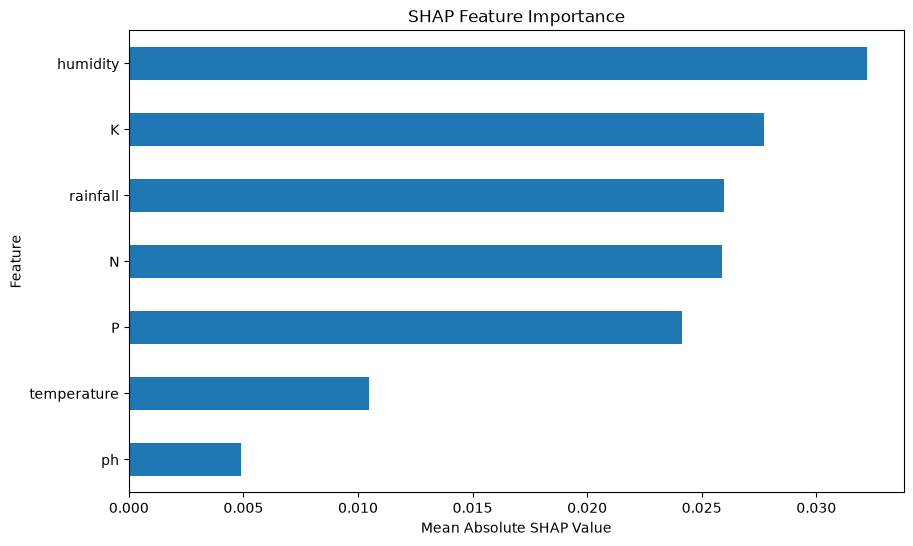

In [35]:
shap_importance.sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("SHAP Feature Importance")
plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.show()

In [36]:
print("Most important feature:", shap_importance.index[0])
print("Least important feature:", shap_importance.index[-1])

Most important feature: humidity
Least important feature: ph


In [37]:
# Example field conditions
sample = pd.DataFrame([{
    "N": 90,
    "P": 42,
    "K": 43,
    "temperature": 20.9,
    "humidity": 82.0,
    "ph": 6.5,
    "rainfall": 202.9
}])

print(sample)

    N   P   K  temperature  humidity   ph  rainfall
0  90  42  43         20.9      82.0  6.5     202.9


In [38]:
prediction = model.predict(sample)[0]

print("🌱 Recommended crop:", prediction)

🌱 Recommended crop: rice


In [39]:
probabilities = model.predict_proba(sample)[0]

probability_df = pd.DataFrame({
    "Crop": model.classes_,
    "Probability": probabilities
}).sort_values(
    "Probability",
    ascending=False
)

probability_df.head(5)

,Crop,Probability
20,rice,0.935
8,jute,0.065
0,apple,0.000
12,mango,0.000
19,pomegranate,0.000


In [40]:
top_crop = probability_df.iloc[0]

print("🌱 Recommended crop:", top_crop["Crop"])
print(f"🤖 Model confidence: {top_crop['Probability'] * 100:.2f}%")

🌱 Recommended crop: rice
🤖 Model confidence: 93.50%


In [41]:
sample_shap = explainer(sample)

print("SHAP explanation generated successfully!")

SHAP explanation generated successfully!


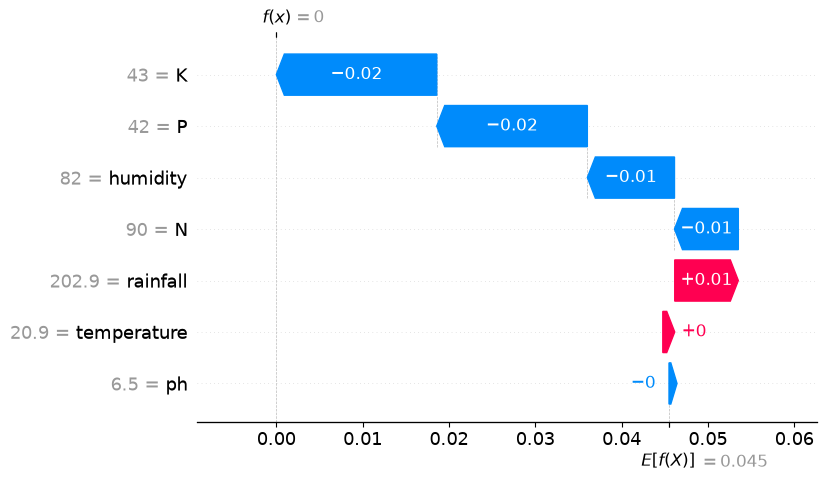

In [42]:
shap.plots.waterfall(
    sample_shap[0, :, 0],
    max_display=7
)

In [43]:
import os

os.makedirs("../models", exist_ok=True)

print("✅ Models folder ready")

✅ Models folder ready


In [44]:
import joblib

model_path = "../models/crop_recommendation_rf.pkl"

joblib.dump(model, model_path)

print("✅ Model saved successfully!")
print("Location:", model_path)

✅ Model saved successfully!
Location: ../models/crop_recommendation_rf.pkl


In [45]:
loaded_model = joblib.load(model_path)

loaded_prediction = loaded_model.predict(sample)[0]

print("Original prediction:", prediction)
print("Loaded model prediction:", loaded_prediction)

print("Same prediction:", prediction == loaded_prediction)

Original prediction: rice
Loaded model prediction: rice
Same prediction: True
